In [ ]:
import pandas as pd

df = pd.read_csv('/content/online_retail.csv', encoding='ISO-8859-1')

# BEFORE CLEANING
print("Before Cleaning:")
df.info()
print(df.isnull().sum())

# CLEANING
df = df.dropna(subset=['Description', 'UnitPrice'])
df = df[df['CustomerID'].notna()]
df = df.drop_duplicates()
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# FEATURE ENGINEERING
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']
df['Month'] = df['InvoiceDate'].dt.month
df['Year'] = df['InvoiceDate'].dt.year

# AFTER CLEANING
print("\nAfter Cleaning:")
df.info()
print(df.isnull().sum())

df.head()
# SAVE
df.to_csv('/content/cleaned_data.csv', index=False)


Before Cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49912 entries, 0 to 49911
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    49912 non-null  object 
 1   StockCode    49912 non-null  object 
 2   Description  49770 non-null  object 
 3   Quantity     49912 non-null  int64  
 4   InvoiceDate  49912 non-null  object 
 5   UnitPrice    49911 non-null  float64
 6   CustomerID   32030 non-null  float64
 7   Country      49911 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 3.0+ MB
InvoiceNo          0
StockCode          0
Description      142
Quantity           0
InvoiceDate        0
UnitPrice          1
CustomerID     17882
Country            1
dtype: int64

After Cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 30622 entries, 0 to 49910
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----   

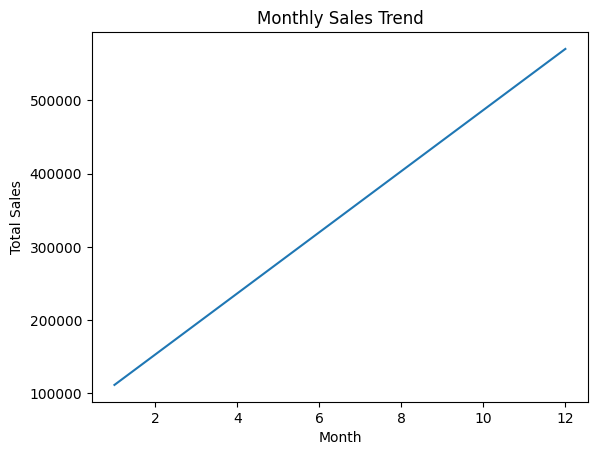

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

plt.figure()
monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

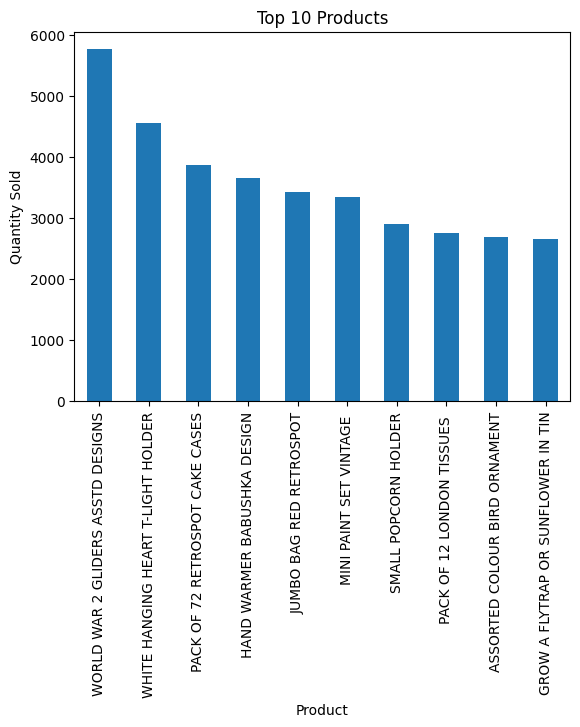

In [ ]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_products.plot(kind='bar')
plt.title("Top 10 Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=90)
plt.show()

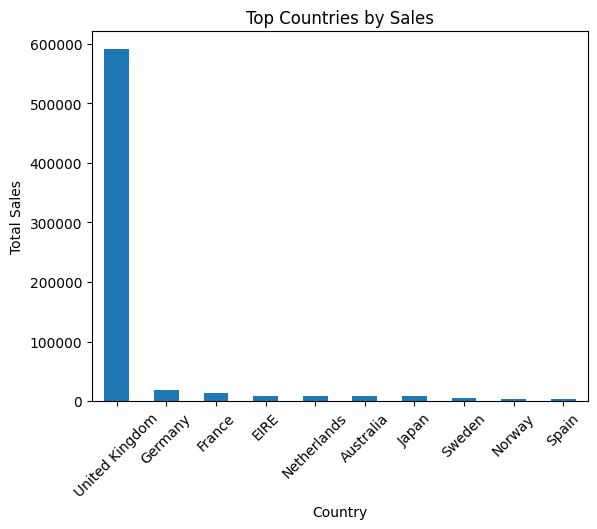

In [ ]:
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure()
country_sales.plot(kind='bar')
plt.title("Top Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

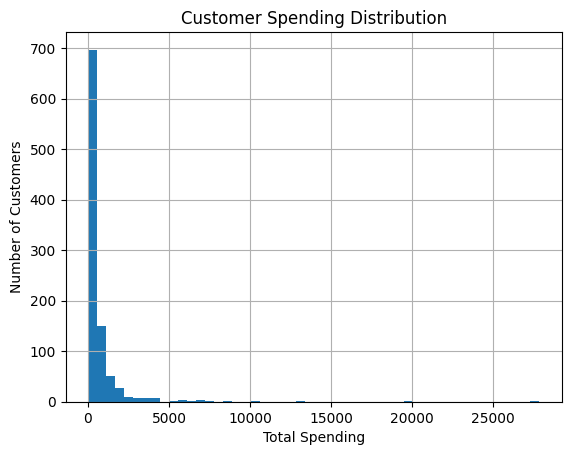

In [ ]:
customer_spending = df.groupby('CustomerID')['TotalPrice'].sum()

plt.figure()
customer_spending.hist(bins=50)
plt.title("Customer Spending Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Number of Customers")
plt.show()

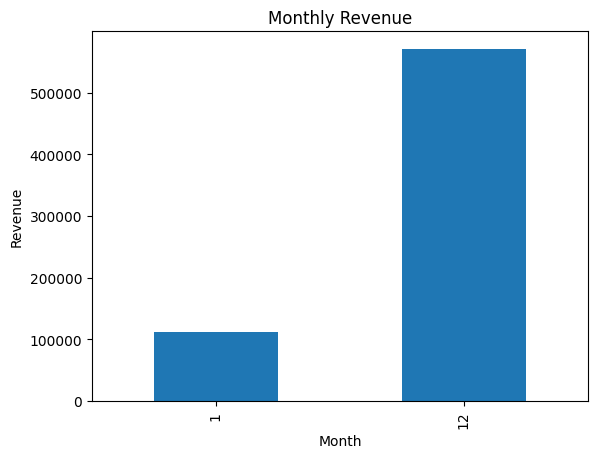

In [ ]:
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

plt.figure()
monthly_sales.plot(kind='bar')
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [28]:
customer_data = df.groupby('CustomerID').agg({
    'TotalPrice': 'sum',     # total spending
    'InvoiceNo': 'count',    # number of purchases
    'Quantity': 'sum'        # total items bought
}).reset_index()

customer_data.columns = ['CustomerID', 'TotalSpending', 'Frequency', 'Quantity']
customer_data.head()

,CustomerID,TotalSpending,Frequency,Quantity
0,12347.0,711.79,31,319
1,12348.0,892.80,17,1254
2,12370.0,1864.27,90,967
3,12377.0,1001.52,43,604
4,12383.0,600.72,37,754


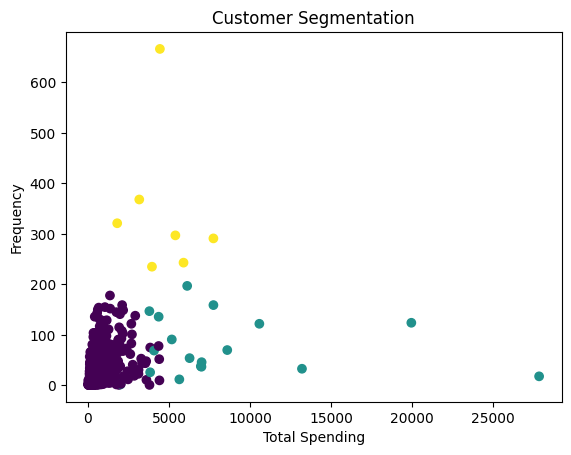

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(customer_data[['TotalSpending', 'Frequency', 'Quantity']])
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
customer_data['Cluster'] = kmeans.fit_predict(scaled_data)
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(customer_data['TotalSpending'], customer_data['Frequency'],
            c=customer_data['Cluster'])
plt.xlabel("Total Spending")
plt.ylabel("Frequency")
plt.title("Customer Segmentation")
plt.show()

In [34]:
customer_data.groupby('Cluster').mean()
customer_data.groupby('Cluster')[['TotalSpending', 'Frequency', 'Quantity']].mean()

,TotalSpending,Frequency,Quantity
Cluster,,,
0,527.357276,28.321014,289.234424
1,8340.026667,76.722222,4983.111111
2,4624.660000,345.857143,2259.142857
